# Spatial Precalculus: Fractions → 3D Space → Apple Vision Pro
### Remote Sensing · Phase Retrieval · Photonics · Biotech Spectroscopy

> **A fraction is a projection.**
> Every image on every screen — phone, Vision Pro headset, satellite camera —
> is computed by dividing by $Z$.
>
> $$x_{\text{screen}} = f \cdot \frac{X}{Z}$$
>
> The same division appears in GS phase retrieval, satellite parallax,
> and the spectroscopy that detects genetically modified red pigment in a forest.

| § | Topic | Math level |
|---|-------|-----------|
| 1 | Fractions as projections | Pre-algebra → precalculus |
| 2 | 3D coordinates and rotation matrices | Precalculus / linear algebra |
| 3 | Quaternions — rotation without gimbal lock | Complex numbers → 4D |
| 4 | Apple Vision Pro stereo depth | Stereo parallax = fraction |
| 5 | Remote sensing → GS phase retrieval bridge | All the above unified |
| 6 | Red pigment / GMO spectral signature | Beer-Lambert + feature importance |


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
sp.init_printing(use_latex='mathjax')
from IPython.display import display

import sys, os
_repo = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _repo not in sys.path:
    sys.path.insert(0, _repo)

from dgs.spatial_computing import (
    perspective_divide, homogeneous_coords, dehomogenize,
    rot_x, rot_y, rot_z, translation_matrix,
    quaternion_from_axis_angle, quaternion_to_matrix,
    quaternion_multiply, quaternion_slerp,
    perspective_matrix, project_points,
    stereo_depth, depth_uncertainty,
    phase_retrieval_vs_stereo_analogy,
    spatial_computing_sympy_5,
)

rng = np.random.default_rng(42)
print("Modules loaded.")


Modules loaded.


---
## §1 — Fractions ARE Projections

A fraction $\frac{a}{b}$ compares two quantities. In 3D space:

$$x_{\text{screen}} = f \cdot \frac{X}{Z}$$

- $f$ = focal length (how zoomed in)
- $X$ = real-world horizontal position
- $Z$ = depth (how far away)

**Bigger $Z$ → smaller image** (things far away look smaller).
This is the central fraction of all computer graphics.

**Cross-multiply** to get the proportion form:
$$\frac{x_{\text{screen}}}{f} = \frac{X}{Z} \quad\Longrightarrow\quad x_{\text{screen}} \cdot Z = f \cdot X$$


In [2]:
X_s, Y_s, Z_s, f_s = sp.symbols('X Y Z f', positive=True)

proj_eq = sp.Eq(sp.Symbol('x_s'), f_s * X_s / Z_s)
print("Perspective projection:"); display(proj_eq)

# Cross-multiplied (proportion form)
cross = sp.Eq(sp.Symbol('x_s') * Z_s, f_s * X_s)
print("Cross-multiplied:"); display(cross)

# Numerical: same object at different depths
f_val = 500   # pixels (typical phone camera)
X_val = 1.0   # 1 meter to the right

print("\nSame object (X=1m), different depths:")
print("  Depth Z    | Screen x  | Appears")
print("  -----------+-----------+--------")
for Z_val in [1, 2, 5, 10, 100]:
    x_s = f_val * X_val / Z_val
    appears = "large" if x_s > 200 else ("medium" if x_s > 50 else "tiny")
    print(f"  Z = {Z_val:4d} m  | {x_s:7.1f} px | {appears}")


Perspective projection:


     X⋅f
xₛ = ───
      Z 

Cross-multiplied:


Z⋅xₛ = X⋅f


Same object (X=1m), different depths:
  Depth Z    | Screen x  | Appears
  -----------+-----------+--------
  Z =    1 m  |   500.0 px | large
  Z =    2 m  |   250.0 px | large
  Z =    5 m  |   100.0 px | medium
  Z =   10 m  |    50.0 px | tiny
  Z =  100 m  |     5.0 px | tiny


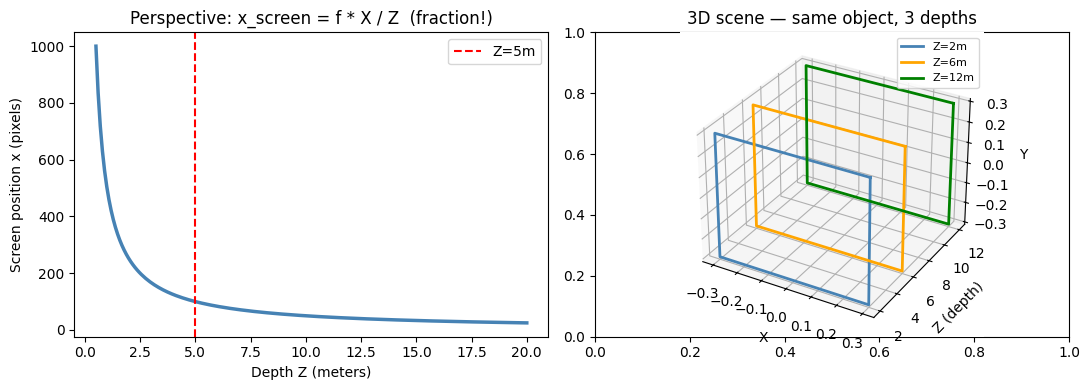

In [3]:
# Visualize: perspective foreshortening
depths = np.linspace(0.5, 20, 200)
screen_x = f_val * 1.0 / depths   # X=1m, varying Z

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(depths, screen_x, 'steelblue', lw=2.5)
ax1.set_xlabel('Depth Z (meters)')
ax1.set_ylabel('Screen position x (pixels)')
ax1.set_title('Perspective: x_screen = f * X / Z  (fraction!)')
ax1.axvline(5, color='red', ls='--', lw=1.5, label='Z=5m')
ax1.legend()

# 3D scene with two boxes at different depths
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for z_obj, col in [(2, 'steelblue'), (6, 'orange'), (12, 'green')]:
    size = 0.3
    # Draw a simple box wireframe
    corners = np.array([[size,size,z_obj],[size,-size,z_obj],
                        [-size,-size,z_obj],[-size,size,z_obj],[size,size,z_obj]])
    ax2.plot(corners[:,0], corners[:,2], corners[:,1], color=col, lw=2,
             label=f'Z={z_obj}m')
ax2.set_xlabel('X'); ax2.set_ylabel('Z (depth)'); ax2.set_zlabel('Y')
ax2.set_title('3D scene — same object, 3 depths')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.savefig('perspective_projection.png', dpi=100); plt.show()


---
## §2 — 3D Rotation Matrices

Every rotation in 3D is a matrix multiply. Three elementary rotations:

$$R_z(\theta) = \begin{pmatrix}\cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1\end{pmatrix}$$

Combine them: $R = R_z R_y R_x$ (order matters — matrix multiplication is not commutative).

**Homogeneous coordinates** add a 4th component so translation is also a matrix multiply:

$$\begin{pmatrix}x'\\y'\\z'\\1\end{pmatrix} = \begin{pmatrix}1&0&0&t_x\\0&1&0&t_y\\0&0&1&t_z\\0&0&0&1\end{pmatrix}\begin{pmatrix}x\\y\\z\\1\end{pmatrix}$$


Rotation matrix Rz(theta):


⎡cos(θ)  -sin(θ)  0⎤
⎢                  ⎥
⎢sin(θ)  cos(θ)   0⎥
⎢                  ⎥
⎣  0        0     1⎦


R^T R (should be identity):


⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

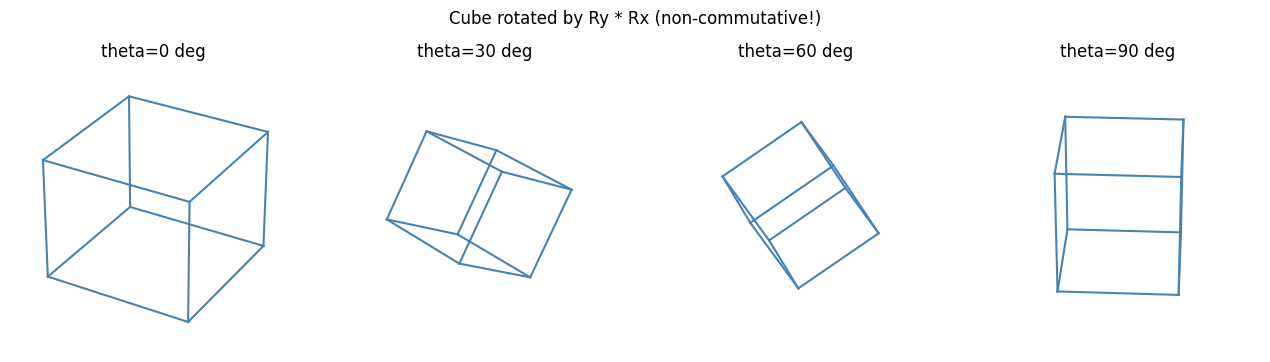

In [4]:
theta, phi_s = sp.symbols('theta phi', real=True)

# Symbolic Rz
Rz = sp.Matrix([
    [sp.cos(theta), -sp.sin(theta), 0],
    [sp.sin(theta),  sp.cos(theta), 0],
    [0, 0, 1]
])
print("Rotation matrix Rz(theta):"); display(Rz)

# Verify it's orthogonal: R^T R = I
check = sp.simplify(Rz.T * Rz)
print("\nR^T R (should be identity):"); display(check)

# Numerical: rotate a cube
def make_cube():
    v = np.array([[s1,s2,s3] for s1 in [-1,1] for s2 in [-1,1] for s3 in [-1,1]], float)
    edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
    return v, edges

v, edges = make_cube()
angles = [0, 30, 60, 90]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5), subplot_kw={'projection':'3d'})
for ax, ang in zip(axes, angles):
    Rx_n = rot_x(np.deg2rad(ang))[:3,:3]
    Ry_n = rot_y(np.deg2rad(ang*0.7))[:3,:3]
    v_rot = (Ry_n @ Rx_n @ v.T).T
    for e in edges:
        pts = v_rot[list(e)]
        ax.plot(pts[:,0], pts[:,2], pts[:,1], 'steelblue', lw=1.5)
    ax.set_title(f'theta={ang} deg')
    ax.set_axis_off()
plt.suptitle('Cube rotated by Ry * Rx (non-commutative!)', y=1.02)
plt.tight_layout(); plt.savefig('rotation_cube.png', dpi=100); plt.show()


---
## §3 — Quaternions: Rotation in 4D (No Gimbal Lock)

A **quaternion** is a 4D complex number:
$$q = w + xi + yj + zk, \quad i^2=j^2=k^2=ijk=-1$$

For rotation by angle $\theta$ around unit axis $\hat{n}$:
$$q = \cos\!\frac{\theta}{2} + \sin\!\frac{\theta}{2}(n_x i + n_y j + n_z k)$$

**Why quaternions?** Euler angles (three angles) hit **gimbal lock** —
two axes align and you lose a degree of freedom. Apple Vision Pro,
every game engine, every drone autopilot uses quaternions.

**SLERP** (spherical linear interpolation) smoothly blends two rotations —
essential for AR animation.


In [5]:
w_s, x_q, y_q, z_q = sp.symbols('w x y z', real=True)
theta_s, n_x, n_y, n_z = sp.symbols('theta n_x n_y n_z', real=True)

q_eq = sp.Eq(sp.Symbol('q'),
             sp.cos(theta_s/2) +
             sp.sin(theta_s/2)*(n_x*sp.Symbol('i') +
                                n_y*sp.Symbol('j') +
                                n_z*sp.Symbol('k')))
print("Unit quaternion for rotation:"); display(q_eq)

norm_sq = sp.Eq(sp.Symbol('|q|^2'), w_s**2 + x_q**2 + y_q**2 + z_q**2)
print("\nNorm squared (must = 1):"); display(norm_sq)


Unit quaternion for rotation:


                              ⎛θ⎞      ⎛θ⎞
q = (i⋅nₓ + j⋅n_y + k⋅n_z)⋅sin⎜─⎟ + cos⎜─⎟
                              ⎝2⎠      ⎝2⎠


Norm squared (must = 1):


        2    2    2    2
|q|² = w  + x  + y  + z 

In [6]:
# Quaternion SLERP: interpolate between two orientations
q0 = quaternion_from_axis_angle([0, 0, 1], 0)           # identity
q1 = quaternion_from_axis_angle([0, 0, 1], np.pi)       # 180 deg around Z

t_vals = np.linspace(0, 1, 9)
print("SLERP interpolation (0 -> 180 deg around Z):")
pt = np.array([1.0, 0.0, 0.0])   # rotate the X unit vector
for t in t_vals:
    q_t = quaternion_slerp(q0, q1, t)
    M   = quaternion_to_matrix(q_t)[:3,:3]
    pt_rot = M @ pt
    angle_deg = np.degrees(np.arccos(np.clip(np.dot(pt, pt_rot), -1, 1)))
    print(f"  t={t:.2f}  q={q_t.round(3)}  rotated_X={pt_rot.round(3)}  angle={angle_deg:.1f} deg")


SLERP interpolation (0 -> 180 deg around Z):
  t=0.00  q=[1. 0. 0. 0.]  rotated_X=[1. 0. 0.]  angle=0.0 deg
  t=0.12  q=[0.981 0.    0.    0.195]  rotated_X=[0.924 0.383 0.   ]  angle=22.5 deg
  t=0.25  q=[0.924 0.    0.    0.383]  rotated_X=[0.707 0.707 0.   ]  angle=45.0 deg
  t=0.38  q=[0.831 0.    0.    0.556]  rotated_X=[0.383 0.924 0.   ]  angle=67.5 deg
  t=0.50  q=[0.707 0.    0.    0.707]  rotated_X=[-0.  1.  0.]  angle=90.0 deg
  t=0.62  q=[0.556 0.    0.    0.831]  rotated_X=[-0.383  0.924  0.   ]  angle=112.5 deg
  t=0.75  q=[0.383 0.    0.    0.924]  rotated_X=[-0.707  0.707  0.   ]  angle=135.0 deg
  t=0.88  q=[0.195 0.    0.    0.981]  rotated_X=[-0.924  0.383  0.   ]  angle=157.5 deg
  t=1.00  q=[0. 0. 0. 1.]  rotated_X=[-1.  0.  0.]  angle=180.0 deg


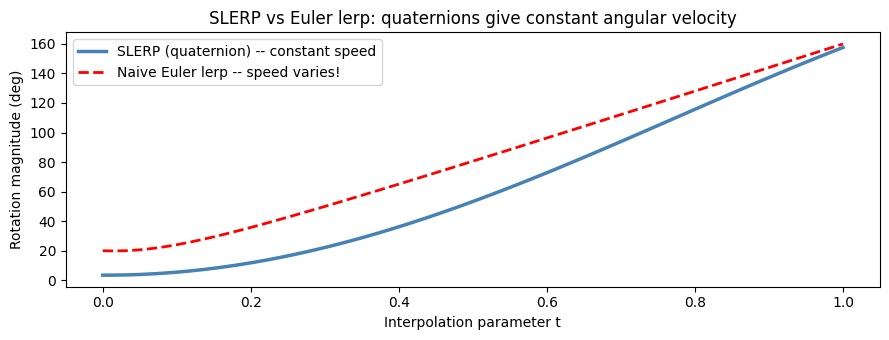

SLERP keeps constant angular speed -> smooth AR animation in Vision Pro


In [7]:
# Visualize SLERP path vs Euler lerp (shows why slerp is better)
n_frames = 60
t_arr = np.linspace(0, 1, n_frames)

# SLERP path
q0_v = quaternion_from_axis_angle([1, 0, 0], np.deg2rad(20))
q1_v = quaternion_from_axis_angle([0, 1, 0], np.deg2rad(160))
slerp_angles = []
for t in t_arr:
    q_t = quaternion_slerp(q0_v, q1_v, t)
    slerp_angles.append(np.linalg.norm(q_t[1:]) * 2 * np.degrees(np.arccos(q_t[0])))

# Naive linear interpolation of Euler angles (bad -- shows inconsistency)
e0 = np.array([20.0, 0, 0])
e1 = np.array([0, 160.0, 0])
lerp_magnitude = [np.linalg.norm((1-t)*e0 + t*e1) for t in t_arr]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_arr, slerp_angles, 'steelblue', lw=2.5, label='SLERP (quaternion) -- constant speed')
ax.plot(t_arr, lerp_magnitude, 'r--', lw=2, label='Naive Euler lerp -- speed varies!')
ax.set_xlabel('Interpolation parameter t'); ax.set_ylabel('Rotation magnitude (deg)')
ax.set_title('SLERP vs Euler lerp: quaternions give constant angular velocity')
ax.legend()
plt.tight_layout(); plt.savefig('slerp.png', dpi=100); plt.show()
print("SLERP keeps constant angular speed -> smooth AR animation in Vision Pro")


---
## §4 — Apple Vision Pro: Stereo Depth from Fractions

The Vision Pro has **two main cameras** (one per eye) separated by $B \approx 6$ cm.
Each pixel in the left image matches a pixel in the right image,
shifted by **disparity** $d$.

$$Z = \frac{B \cdot f}{d}$$

This is:
1. The **same fraction** from §1 (divide to find depth)
2. The **same equation** as satellite stereo (§4 of the last notebook)
3. The **same math** as GS phase retrieval — inverting a projection

Apple uses this for:
- Hand tracking (knowing exactly where your fingers are in 3D)
- Spatial audio (knowing distance to virtual sound sources)
- Pass-through video (compositing real and virtual objects at correct depth)


In [8]:
# Vision Pro stereo parameters (approximate)
B_vp  = 0.063    # m  (inter-camera baseline)
f_vp  = 800.0    # px (approximate focal length)
sigma_d = 0.5    # px (sub-pixel disparity accuracy)

disp_arr = np.linspace(1, 80, 300)
Z_arr    = stereo_depth(disp_arr, B_vp, f_vp)["depth_m"]
dZ_arr   = depth_uncertainty(Z_arr, B_vp, f_vp, sigma_d)

print("Apple Vision Pro stereo depth:")
print(f"  Baseline B = {B_vp*100:.1f} cm  focal f = {f_vp:.0f} px")
print()
print(f"  {'Disparity':>10} | {'Depth Z':>10} | {'Depth err dZ':>14}")
print("  " + "-"*40)
for d_v in [2, 5, 10, 20, 40]:
    Z_v  = B_vp * f_vp / d_v
    dZ_v = Z_v**2 * sigma_d / (B_vp * f_vp)
    print(f"  {d_v:>10.0f} | {Z_v:>10.3f} m | {dZ_v*100:>12.2f} cm")


Apple Vision Pro stereo depth:
  Baseline B = 6.3 cm  focal f = 800 px

   Disparity |    Depth Z |   Depth err dZ
  ----------------------------------------
           2 |     25.200 m |       630.00 cm
           5 |     10.080 m |       100.80 cm
          10 |      5.040 m |        25.20 cm
          20 |      2.520 m |         6.30 cm
          40 |      1.260 m |         1.57 cm


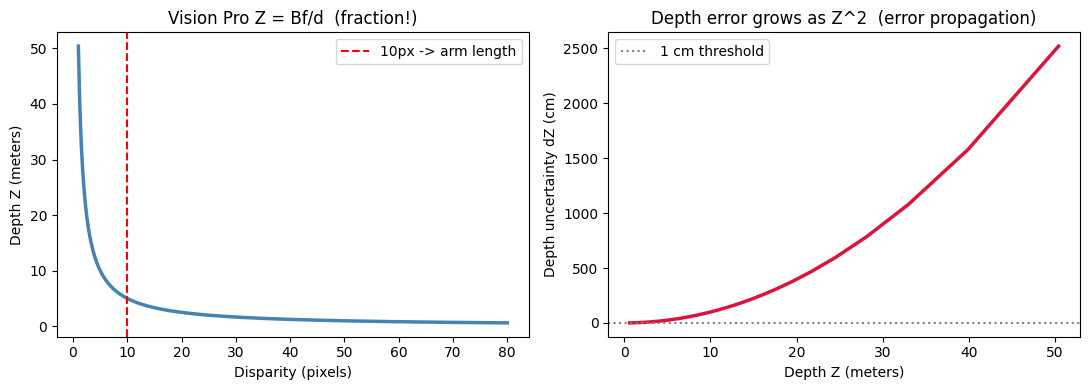

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(disp_arr, Z_arr, 'steelblue', lw=2.5)
ax1.set_xlabel('Disparity (pixels)')
ax1.set_ylabel('Depth Z (meters)')
ax1.set_title('Vision Pro Z = Bf/d  (fraction!)')
ax1.axvline(10, color='red', ls='--', label='10px -> arm length')
ax1.legend()

ax2.plot(Z_arr, dZ_arr*100, 'crimson', lw=2.5)
ax2.set_xlabel('Depth Z (meters)')
ax2.set_ylabel('Depth uncertainty dZ (cm)')
ax2.set_title('Depth error grows as Z^2  (error propagation)')
ax2.axhline(1.0, color='gray', ls=':', label='1 cm threshold')
ax2.legend()

plt.tight_layout(); plt.savefig('vision_pro_depth.png', dpi=100); plt.show()


---
## §5 — The Bridge: Stereo · Remote Sensing · GS Phase Retrieval

All three are the same mathematical problem:

> **Given 2D intensity measurements, recover a hidden dimension.**

| System | Observed | Hidden | Method |
|--------|----------|--------|--------|
| Stereo (Vision Pro / satellite) | 2 intensity images | 3D depth $Z$ | $Z = Bf/d$ |
| Remote sensing | Spectral intensities $I(\lambda)$ | Material class | Feature importance + RF |
| GS phase retrieval | $|E_{\text{in}}|^2$, $|E_{\text{out}}|^2$ | Phase $\phi(\omega)$ | Alternate projections |
| Photonic circuits | $|E_{\text{out}}|^2$ vs voltage | Coupling coefficient $\kappa$ | Inverse transfer matrix |

The common structure:

$$\text{Observed} = |\text{projection of Hidden}|^2 \quad\Longrightarrow\quad \text{Hidden} = \text{invert the projection}$$

In all cases: **you see intensities (magnitudes squared), and you want the field (complex amplitude)**.


=== Unified projection-inversion framework ===

Stereo imaging:
  known     : Two 2D intensity images I_L, I_R
  unknown   : 3D depth Z(x,y)
  method    : Disparity d = match features; Z = Bf/d
  equation  : Z = B*f/d

GS phase retrieval:
  known     : Two intensity spectra |E_in|^2, |E_out|^2
  unknown   : Phase phi(omega) of E_out
  method    : Alternate projections in object/Fourier domain
  equation  : phi = angle(IFFT(sqrt(I_out) * exp(i*phi_estimate)))

Remote sensing:
  known     : Multispectral intensity I(lambda)
  unknown   : Land cover class, material composition
  method    : Feature importance -> decision tree
  equation  : class = argmax P(class | NDVI, NIR, Red, ...)

Common math: All three invert a projection: recover hidden dimensions from observed intensities


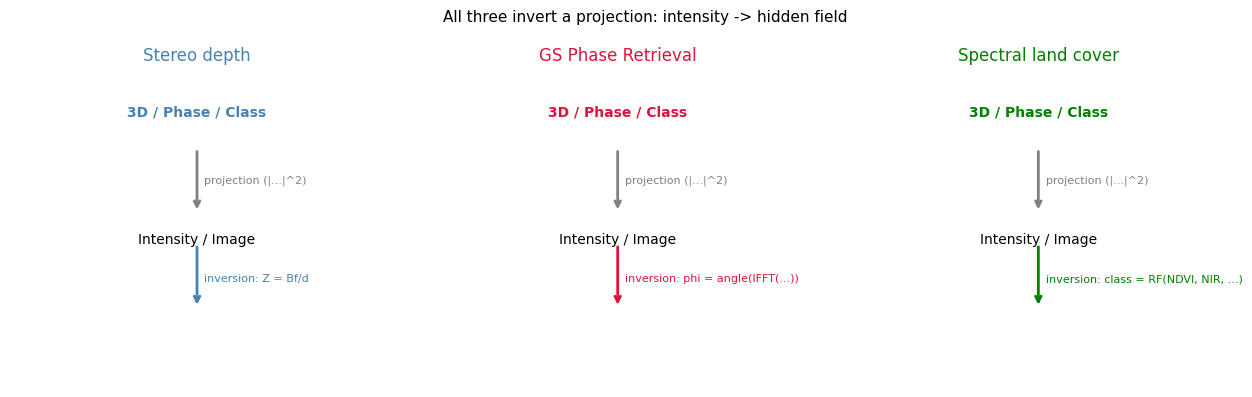

In [10]:
analogy = phase_retrieval_vs_stereo_analogy()
print("=== Unified projection-inversion framework ===")
for system, info in analogy.items():
    if isinstance(info, dict):
        print(f"\n{system}:")
        for k, v in info.items():
            print(f"  {k:<10}: {v}")
    else:
        print(f"\nCommon math: {info}")

# Visualize the shared structure
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = ['Stereo depth', 'GS Phase Retrieval', 'Spectral land cover']
colors = ['steelblue', 'crimson', 'green']
notes  = ['Z = Bf/d', 'phi = angle(IFFT(...))', 'class = RF(NDVI, NIR, ...)']

for ax, title, col, note in zip(axes, titles, colors, notes):
    # Draw the same "projection then inversion" diagram
    ax.annotate('3D / Phase / Class', xy=(0.5, 0.85), xytext=(0.5, 0.85),
                ha='center', fontsize=10, color=col, fontweight='bold',
                transform=ax.transAxes)
    ax.annotate('', xy=(0.5, 0.55), xytext=(0.5, 0.75),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))
    ax.text(0.52, 0.64, 'projection (|...|^2)', transform=ax.transAxes,
            fontsize=8, color='gray')
    ax.annotate('Intensity / Image', xy=(0.5, 0.45), xytext=(0.5, 0.45),
                ha='center', fontsize=10, color='black',
                transform=ax.transAxes)
    ax.annotate('', xy=(0.5, 0.25), xytext=(0.5, 0.45),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.text(0.52, 0.33, 'inversion: ' + note, transform=ax.transAxes,
            fontsize=8, color=col)
    ax.set_title(title, color=col)
    ax.axis('off')

plt.suptitle('All three invert a projection: intensity -> hidden field', fontsize=11)
plt.tight_layout(); plt.savefig('unified_bridge.png', dpi=100); plt.show()


---
## §6 — Red Pigment & Biotech: Spectral Signature of GMO Anthocyanin

Plants use two main pigments for photosynthesis:
- **Chlorophyll a/b**: absorbs strongly at 430 nm and 680 nm (blue + red), reflects green
- **Anthocyanin**: red/purple pigment, absorbs at 520–550 nm, reflects red

A **genetically modified** forest with over-expressed anthocyanin
(drought-resistance enhancement, e.g., *Pinus radiata* experiments)
produces a measurably different spectral signature than normal forest.

**Feature importance** from a satellite tells us which wavelength bands
most strongly discriminate GMO vs normal trees — a hypothesis test on spectral data.


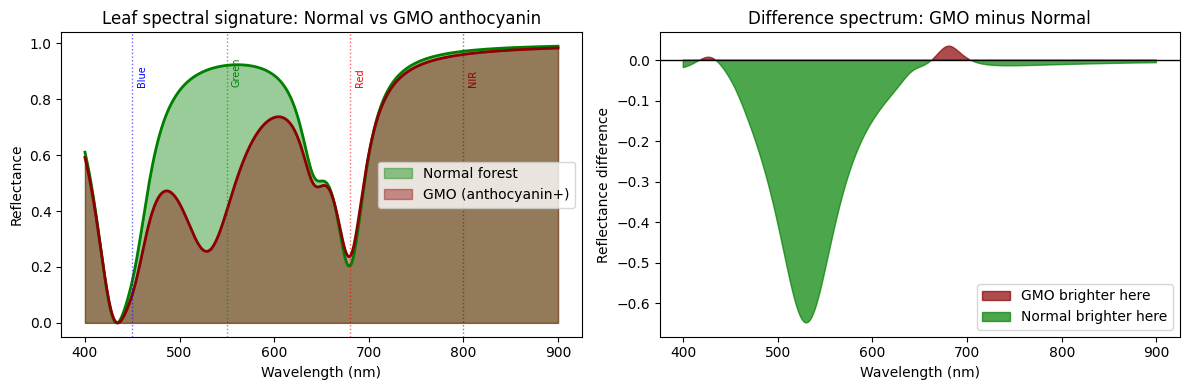

In [11]:
# Absorption spectra: normal forest vs anthocyanin-enhanced GMO
wavelength = np.linspace(400, 900, 500)   # nm

def lorentzian(lam, lam0, width, amp):
    return amp / (1 + ((lam - lam0)/width)**2)

# Chlorophyll a: peaks at 430nm, 680nm
chl_a = lorentzian(wavelength, 430, 25, 1.0) + lorentzian(wavelength, 680, 20, 0.9)
# Chlorophyll b: peaks at 453nm, 642nm (shifted slightly)
chl_b = lorentzian(wavelength, 453, 22, 0.7) + lorentzian(wavelength, 642, 18, 0.6)

# Anthocyanin: peak at 530nm (absorbs green, reflects red)
antho = lorentzian(wavelength, 530, 40, 1.2)

# Normal leaf: mostly chlorophyll
normal = 0.8*chl_a + 0.5*chl_b
# GMO leaf: extra anthocyanin
gmo    = 0.8*chl_a + 0.5*chl_b + 0.6*antho

# Reflectance = 1 - normalized absorption
norm_n = 1 - normal / normal.max()
norm_g = 1 - gmo    / gmo.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.fill_between(wavelength, 0, norm_n, alpha=0.4, color='green', label='Normal forest')
ax1.fill_between(wavelength, 0, norm_g, alpha=0.4, color='darkred', label='GMO (anthocyanin+)')
ax1.plot(wavelength, norm_n, 'green', lw=2)
ax1.plot(wavelength, norm_g, 'darkred', lw=2)
ax1.set_xlabel('Wavelength (nm)'); ax1.set_ylabel('Reflectance')
ax1.set_title('Leaf spectral signature: Normal vs GMO anthocyanin')
ax1.legend()
# Color band markers
for lam_c, col, name in [(450,'blue','Blue'),(550,'green','Green'),
                          (680,'red','Red'),(800,'darkred','NIR')]:
    ax1.axvline(lam_c, color=col, ls=':', lw=1, alpha=0.6)
    ax1.text(lam_c+5, 0.85, name, color=col, fontsize=7, rotation=90)

# Difference spectrum (what satellite sees as difference)
diff = norm_g - norm_n
ax2.fill_between(wavelength, 0, diff, where=diff>0, color='darkred', alpha=0.7,
                 label='GMO brighter here')
ax2.fill_between(wavelength, 0, diff, where=diff<0, color='green', alpha=0.7,
                 label='Normal brighter here')
ax2.axhline(0, color='black', lw=1)
ax2.set_xlabel('Wavelength (nm)'); ax2.set_ylabel('Reflectance difference')
ax2.set_title('Difference spectrum: GMO minus Normal')
ax2.legend()

plt.tight_layout(); plt.savefig('gmo_spectrum.png', dpi=100); plt.show()


Feature importance for GMO detection:
  1. Green      (550 nm): 0.5366  *** KEY BAND
  2. Blue       (450 nm): 0.2702  *** KEY BAND
  3. Red        (680 nm): 0.1213  
  4. NIR1       (800 nm): 0.0343  
  5. RedEdge    (750 nm): 0.0286  
  6. NIR2       (865 nm): 0.0091  


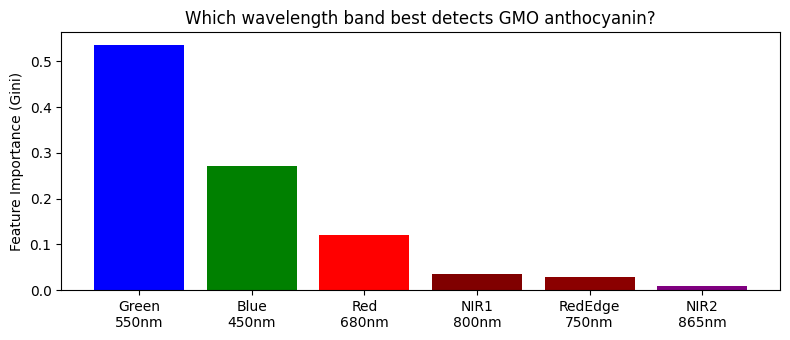

In [12]:
# Feature importance: which wavelength band best detects GMO?
from sklearn.ensemble import RandomForestClassifier

# Simulate satellite multispectral observation: 6 bands
# Band centers: 450, 550, 680, 750, 800, 865 nm
band_centers = [450, 550, 680, 750, 800, 865]
band_names   = ['Blue', 'Green', 'Red', 'RedEdge', 'NIR1', 'NIR2']

def reflectance_at(spectrum, lam_arr, band_nm):
    idx = np.argmin(np.abs(lam_arr - band_nm))
    return spectrum[idx]

N_trees = 400
X_bio = np.zeros((N_trees, 6))
y_bio = np.zeros(N_trees, int)

for i in range(N_trees):
    is_gmo = i >= N_trees // 2
    y_bio[i] = int(is_gmo)
    base = norm_g if is_gmo else norm_n
    noise = rng.normal(0, 0.02, len(wavelength))
    spec = base + noise
    for j, band in enumerate(band_centers):
        X_bio[i, j] = reflectance_at(spec, wavelength, band)

rf_bio = RandomForestClassifier(n_estimators=200, random_state=42)
rf_bio.fit(X_bio, y_bio)
imp_bio = rf_bio.feature_importances_

print("Feature importance for GMO detection:")
idx_sorted = np.argsort(imp_bio)[::-1]
for rank, i in enumerate(idx_sorted):
    print(f"  {rank+1}. {band_names[i]:<10} ({band_centers[i]} nm): "
          f"{imp_bio[i]:.4f}  {'*** KEY BAND' if imp_bio[i] > 0.20 else ''}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(6), imp_bio[idx_sorted], color=['blue','green','red','maroon','darkred','purple'])
ax.set_xticks(range(6))
ax.set_xticklabels([band_names[i] + f"\n{band_centers[i]}nm" for i in idx_sorted])
ax.set_ylabel('Feature Importance (Gini)')
ax.set_title('Which wavelength band best detects GMO anthocyanin?')
plt.tight_layout(); plt.savefig('gmo_importance.png', dpi=100); plt.show()


---
## §7 — All Equations in One Place (SymPy)

Every formula in this notebook descends from one precalculus fraction: $a/b = c/d$.


In [13]:
sp.init_printing(use_latex='mathjax')
eqs = spatial_computing_sympy_5()
for name, eq in eqs.items():
    print(f"{name}:"); display(eq)

# Beer-Lambert (biotech)
A_sym, eps, c_sym, L_sym = sp.symbols('A epsilon c L', positive=True)
beer = sp.Eq(A_sym, eps * c_sym * L_sym)
print("\nBeer-Lambert (anthocyanin concentration):"); display(beer)

# GS phase retrieval iteration
E_sym = sp.Symbol('E')
phi_n = sp.Symbol('phi_n')
gs_update = sp.Eq(sp.Symbol('E_{n+1}'),
                  sp.sqrt(sp.Symbol('I_target')) * sp.exp(sp.I * phi_n))
print("\nGS phase retrieval update step:"); display(gs_update)


Perspective_divide:


     X⋅f
xₛ = ───
      Z 

Quaternion_rotation:


            ⎛θ⎞      ⎛θ⎞
q = nₕₐₜ⋅sin⎜─⎟ + cos⎜─⎟
            ⎝2⎠      ⎝2⎠

Stereo_depth:


...

       ⎡X⋅f⎤
       ⎢───⎥
⎡xₛ⎤   ⎢ Z ⎥
⎢  ⎥   ⎢   ⎥
⎢yₛ⎥ = ⎢Y⋅f⎥
⎢  ⎥   ⎢───⎥
⎣1 ⎦   ⎢ Z ⎥
       ⎢   ⎥
       ⎣ 1 ⎦


Beer-Lambert (anthocyanin concentration):


A = L⋅c⋅ε


GS phase retrieval update step:


            __________  ⅈ⋅φₙ
E_{n+1} = ╲╱ I_target ⋅ℯ    

---
## Summary

| Math level | Concept | Application |
|-----------|---------|-------------|
| Pre-algebra fraction $a/b$ | $x_s = fX/Z$ | Screen projection |
| Precalculus ratios | $Z = Bf/d$ | Vision Pro hand tracking, satellite stereo |
| Linear algebra | $R = R_z R_y R_x$ | 3D rotation |
| Complex numbers | Quaternion $q = \cos(\theta/2) + \sin(\theta/2)\hat{n}$ | Smooth AR animation (SLERP) |
| Beer-Lambert $A = \varepsilon c L$ | Anthocyanin absorbs at 530 nm | GMO forest detection from satellite |
| GS algorithm | Alternate projections | Phase retrieval from intensity |

**The thread from precalculus to Jalali lab**:
fraction → perspective divide → stereo depth → satellite parallax →
multispectral feature importance → GS phase retrieval.
The same $a/b = c/d$ runs through all of it.
